# Thread Implementation Analysis Report

## Methods

In this lab, I refactored the code to remove Boolean variables being used in my ISR callback functions to indicate that buttons have been pressed to now I use kernel events in a single bit array called button_events. 

In this lab, I used the oscilliscope to verify my changes in the code for thread creation for the heartbeat LED. I connected the probes to the LED pins in the board and configured the setting to have a sample rate of 5000 samples per second and 50,000 samples were collected (10 seconds of data). The voltage signal for all LEDs ranges from 0V (LED off) - 3.3V (LED on), with some noise seen on both ends. The data was exported to a CSV file, which contains the time-voltage pairings for analysis. 

## Results

In [51]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def load_oscilloscope_data(filename):
    df = pd.read_csv(filename, skiprows=1, names=["Time (s)", "Voltage (V)"])
    df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
    df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].astype(str).str.replace("+", "", regex=False), errors="coerce")
    df = df.dropna()
    return df["Time (s)"].to_numpy(), df["Voltage (V)"].to_numpy()

def detect_pulses(time, voltage, threshold=1.5, invert=False):
    if invert:
        binary_signal = (voltage < threshold).astype(int)
    else:
        binary_signal = (voltage > threshold).astype(int)
    
    rising_edges = np.where(np.diff(binary_signal) > 0)[0]
    falling_edges = np.where(np.diff(binary_signal) < 0)[0]
    
    rising_times = time[rising_edges]
    falling_times = time[falling_edges]
    
    return rising_times, falling_times

def calculate_duty_cycles(rising_times, falling_times):
    duty_cycles = []
    pulse_widths = []
    periods = []

    if len(rising_times) < 2:
        return np.array([]), np.array([]), np.array([])
    
    for i in range(len(rising_times) - 1):
        rising = rising_times[i]
        
        falling_after = falling_times[falling_times > rising]
        if len(falling_after) == 0:
            continue
        falling = falling_after[0]

        pulse_width = falling - rising
        
        period = rising_times[i + 1] - rising
        
        duty_cycle = (pulse_width / period) * 100
        
        duty_cycles.append(duty_cycle)
        pulse_widths.append(pulse_width)
        periods.append(period)
    
    return np.array(duty_cycles), np.array(pulse_widths), np.array(periods)

def calculate_statistics(data, confidence=0.95):
    if len(data) == 0:
        return None
    
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    sem = stats.sem(data)
    
    ci = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    ci_range = ci[1] - mean
    
    return {
        'mean': mean,
        'std': std,
        'sem': sem,
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'ci_range': ci_range,
        'n_samples': len(data)
    }

def analyze_duty_cycle(filename, nominal_duty=25.0, nominal_freq=1.0, threshold=1.5, invert=False):
    time, voltage = load_oscilloscope_data(filename)
    print(f"Voltage range: {voltage.min():.3f} to {voltage.max():.3f} V")
    print(f"Threshold: {threshold} V")

    rising_times, falling_times = detect_pulses(time, voltage, threshold, invert)
    
    duty_cycles, pulse_widths, periods = calculate_duty_cycles(rising_times, falling_times)

    
    if len(duty_cycles) == 0:
        print("ERROR: No complete pulses detected!")
        return None
    
    duty_stats = calculate_statistics(duty_cycles)
    width_stats = calculate_statistics(pulse_widths)
    period_stats = calculate_statistics(periods)
    
    frequencies = 1.0 / periods
    freq_stats = calculate_statistics(frequencies)
    
    print(f"\nDUTY CYCLE:")
    print(f"   Mean: {duty_stats['mean']:.3f}%")
    print(f"   Std Dev: {duty_stats['std']:.3f}%")
    print(f"   95% CI: [{duty_stats['ci_lower']:.3f}%, {duty_stats['ci_upper']:.3f}%]")
    print(f"   Nominal: {nominal_duty:.3f}%")
    print(f"   Error: {duty_stats['mean'] - nominal_duty:.3f}% ({((duty_stats['mean'] - nominal_duty)/nominal_duty)*100:.2f}% relative error)")
    
    print(f"\nPULSE WIDTH (HIGH time):")
    print(f"   Mean: {width_stats['mean']*1000:.3f} ms")
    print(f"   Std Dev: {width_stats['std']*1000:.3f} ms")
    print(f"   Expected (25% of 1s): {nominal_duty/100 * (1/nominal_freq) * 1000:.3f} ms")
    print(f"\n")
    
    results = {
        'duty_cycles': duty_cycles,
        'pulse_widths': pulse_widths,
        'periods': periods,
        'frequencies': frequencies,
        'duty_stats': duty_stats,
        'width_stats': width_stats,
        'period_stats': period_stats,
        'freq_stats': freq_stats,
        'time': time,
        'voltage': voltage,
        'threshold': threshold
    }
    
    return results

def plot_duty_cycle_results(results, nominal_duty=25.0, nominal_freq=1.0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.hist(results['duty_cycles'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(nominal_duty, color='red', linestyle='--', linewidth=2.5, 
                label=f'Nominal: {nominal_duty}%')
    ax1.axvline(results['duty_stats']['mean'], color='darkblue', linestyle='-', linewidth=2.5,
                label=f"Mean: {results['duty_stats']['mean']:.2f}%")
    ax1.axvline(results['duty_stats']['ci_lower'], color='orange', linestyle=':', linewidth=2,
                label='95% CI bounds')
    ax1.axvline(results['duty_stats']['ci_upper'], color='orange', linestyle=':', linewidth=2)
    ax1.set_xlabel('Duty Cycle (%)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title('Duty Cycle Distribution', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

    deviation = results['duty_stats']['mean'] - nominal_duty
    error = results['duty_stats']['ci_range']
    
    ax2.errorbar(0, deviation, yerr=error, fmt='o', capsize=10, markersize=15, 
                 linewidth=3, color='coral', ecolor='darkred',
                 label=f"Measured: {results['duty_stats']['mean']:.2f}%")
    ax2.axhline(0, color='black', linestyle='--', linewidth=2, 
                label=f'Nominal: {nominal_duty}%')
    ax2.set_xlim(-0.5, 0.5)
    ax2.set_xticks([0])
    ax2.set_xticklabels(['Oscilloscope'])
    ax2.set_ylabel('Duty Cycle Deviation from Nominal (%)', fontsize=12)
    ax2.set_title('Duty Cycle Accuracy with 95% CI', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle('PWM Duty Cycle Analysis (25% @ 1Hz)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

def create_summary_table(results, nominal_duty=25.0, nominal_freq=1.0):

    print(f"{'Parameter':<25} {'Measured':<20} {'Nominal':<15} {'Error':<15}")
    print("-" * 70)
    print(f"{'Duty Cycle':<25} {results['duty_stats']['mean']:.3f} ± {results['duty_stats']['ci_range']:.3f}%"
          f"{nominal_duty:>12.3f}%   {results['duty_stats']['mean']-nominal_duty:>10.3f}%")
    print(f"{'Pulse Width':<25} {results['width_stats']['mean']*1000:.3f} ± {results['width_stats']['ci_range']*1000:.3f} ms"
          f"{(nominal_duty/100)*(1/nominal_freq)*1000:>10.3f} ms  {(results['width_stats']['mean']-(nominal_duty/100)*(1/nominal_freq))*1000:>10.3f} ms")
    print(f"{'Frequency':<25} {results['freq_stats']['mean']:.6f} ± {results['freq_stats']['ci_range']:.6f} Hz"
          f"{nominal_freq:>10.6f} Hz {results['freq_stats']['mean']-nominal_freq:>10.6f} Hz")
    print(f"{'Period':<25} {results['period_stats']['mean']:.6f} ± {results['period_stats']['ci_range']:.6f} s"
          f"{1/nominal_freq:>10.6f} s  {results['period_stats']['mean']-(1/nominal_freq):>10.6f} s")

## Heartbeat LED Analysis

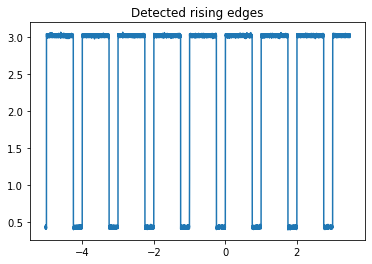

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("heartbeat_led_kernel.csv")

t = data["second"].to_numpy()
v = data["Volt"].to_numpy()

v = data["Volt"].astype(str).str.replace('+', '', regex=False).astype(float)

dv = np.diff(v)

low_th = 1.0    
high_th = 2.0 
is_high = v > high_th

edges = np.where(np.diff(is_high.astype(int)) == 1)[0]

t_edges = t[edges]
v_edges = v[edges]

plt.plot(t, v)
plt.title("Detected rising edges")
plt.show()

Voltage range: 0.394 to 3.068 V
Threshold: 1.5 V

DUTY CYCLE:
   Mean: 25.009%
   Std Dev: 0.010%
   95% CI: [25.000%, 25.018%]
   Nominal: 25.000%
   Error: 0.009% (0.04% relative error)

PULSE WIDTH (HIGH time):
   Mean: 250.143 ms
   Std Dev: 0.098 ms
   Expected (25% of 1s): 250.000 ms


Parameter                 Measured             Nominal         Error          
----------------------------------------------------------------------
Duty Cycle                25.009 ± 0.009%      25.000%        0.009%
Pulse Width               250.143 ± 0.090 ms   250.000 ms       0.143 ms
Frequency                 0.999800 ± 0.000000 Hz  1.000000 Hz  -0.000200 Hz
Period                    1.000200 ± 0.000000 s  1.000000 s    0.000200 s


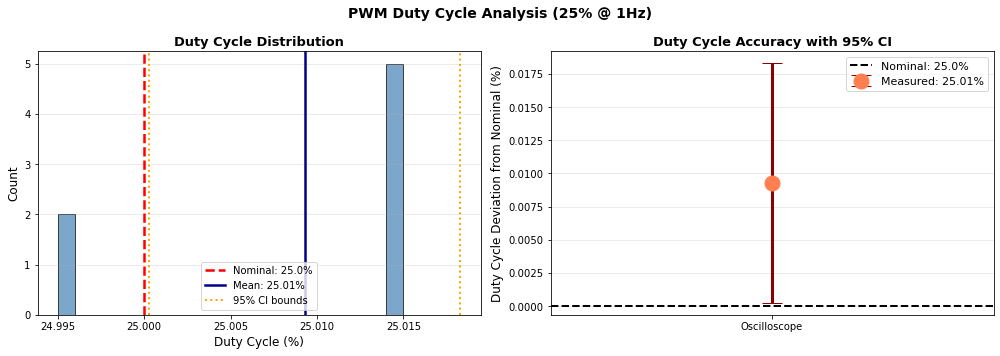

In [53]:
if __name__ == "__main__":
    results = analyze_duty_cycle(
        "heartbeat_led_kernel.csv",
        nominal_duty=25.0,
        nominal_freq=1.0,
        threshold=1.5,
        invert=True 
    )
    
    if results is not None:
        fig = plot_duty_cycle_results(results, nominal_duty=25.0, nominal_freq=1.0)

        create_summary_table(results, nominal_duty=25.0, nominal_freq=1.0)
        
        plt.show()
    else:
        print("Analysis failed. Check your threshold and data.")

In [54]:
import pandas as pd
import numpy as np
import scipy.stats as stats  
import matplotlib.pyplot as plt

data = pd.read_csv("heartbeat_led_kernel.csv")

data["Volt"] = data["Volt"].astype(str).str.replace("+", "", regex=False).astype(float)
v = data["Volt"].to_numpy()
t = data["second"].to_numpy()

high_mask = v > 3.0  
low_mask  = v < 0.5  

v_high = v[high_mask]
v_low = v[low_mask]

ci_high = stats.t.interval(
    0.95, len(v_high)-1, loc=np.mean(v_high), scale=stats.sem(v_high)
)

ci_low = stats.t.interval(
    0.95, len(v_low)-1, loc=np.mean(v_low), scale=stats.sem(v_low)
)

print("95% Confidence Interval (High level):", ci_high)
print("95% Confidence Interval (Low level):", ci_low)


95% Confidence Interval (High level): (3.022413090576337, 3.022627210743827)
95% Confidence Interval (Low level): (0.4309959386653013, 0.43140001199045264)


## Action LED at 1 Hz Analysis

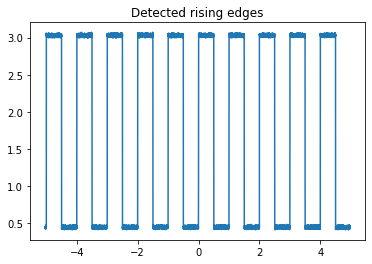

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("action_1hz_kernel.csv")

t = data["second"].to_numpy()
v = data["Volt"].to_numpy()

v = data["Volt"].astype(str).str.replace('+', '', regex=False).astype(float)

dv = np.diff(v)

low_th = 1.0
high_th = 2.5 

is_high = v > high_th

edges = np.where(np.diff(is_high.astype(int)) == 1)[0]

t_edges = t[edges]
v_edges = v[edges]

plt.plot(t, v)
plt.title("Detected rising edges")
plt.show()



Voltage range: 0.404 to 3.073 V
Threshold: 1.5 V

DUTY CYCLE:
   Mean: 49.999%
   Std Dev: 0.006%
   95% CI: [49.994%, 50.004%]
   Nominal: 50.000%
   Error: -0.001% (-0.00% relative error)

PULSE WIDTH (HIGH time):
   Mean: 500.000 ms
   Std Dev: 0.100 ms
   Expected (25% of 1s): 500.000 ms


Parameter                 Measured             Nominal         Error          
----------------------------------------------------------------------
Duty Cycle                49.999 ± 0.005%      50.000%       -0.001%
Pulse Width               500.000 ± 0.077 ms   500.000 ms       0.000 ms
Frequency                 0.999978 ± 0.000092 Hz  1.000000 Hz  -0.000022 Hz
Period                    1.000022 ± 0.000092 s  1.000000 s    0.000022 s


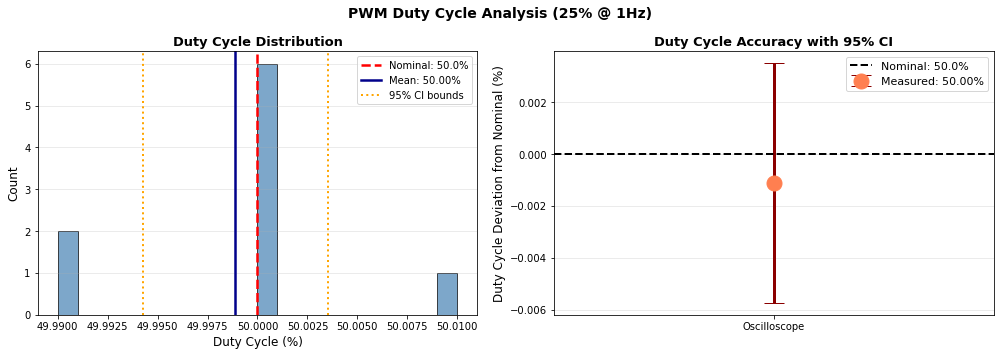

In [56]:
if __name__ == "__main__":
    results = analyze_duty_cycle(
        "action_1hz_kernel.csv",
        nominal_duty=50.0,
        nominal_freq=1.0,
        threshold=1.5,
        invert=True
    )
    
    if results is not None:
        fig = plot_duty_cycle_results(results, nominal_duty=50.0, nominal_freq=1.0)
        
        create_summary_table(results, nominal_duty=50.0, nominal_freq=1.0)
        
        plt.show()
    else:
        print("Analysis failed. Check your threshold and data.")

In [57]:
import pandas as pd
import numpy as np
import scipy.stats as stats  
import matplotlib.pyplot as plt

data = pd.read_csv("action_1hz_kernel.csv")

data["Volt"] = data["Volt"].astype(str).str.replace("+", "", regex=False).astype(float)
v = data["Volt"].to_numpy()
t = data["second"].to_numpy()

high_mask = v > 3.0  
low_mask  = v < 0.5 

v_high = v[high_mask]
v_low = v[low_mask]

ci_high = stats.t.interval(
    0.95, len(v_high)-1, loc=np.mean(v_high), scale=stats.sem(v_high)
)

ci_low = stats.t.interval(
    0.95, len(v_low)-1, loc=np.mean(v_low), scale=stats.sem(v_low)
)

print("95% Confidence Interval (High level):", ci_high)
print("95% Confidence Interval (Low level):", ci_low)


95% Confidence Interval (High level): (3.0322588374037256, 3.0325211518463453)
95% Confidence Interval (Low level): (0.44244421402408846, 0.4427014234909223)


## Action LED at 2 Hz Analysis

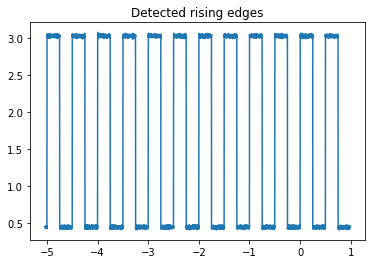

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("action_2hz_kernel.csv")

t = data["second"].to_numpy()
v = data["Volt"].to_numpy()

v = data["Volt"].astype(str).str.replace('+', '', regex=False).astype(float)

dv = np.diff(v)

low_th = 1.0    
high_th = 2.5 

is_high = v > high_th

edges = np.where(np.diff(is_high.astype(int)) == 1)[0]

t_edges = t[edges]
v_edges = v[edges]

plt.plot(t, v)
plt.title("Detected rising edges")
plt.show()



Voltage range: 0.404 to 3.083 V
Threshold: 2.0 V

DUTY CYCLE:
   Mean: 50.002%
   Std Dev: 0.024%
   95% CI: [49.985%, 50.018%]
   Nominal: 50.000%
   Error: 0.002% (0.00% relative error)

PULSE WIDTH (HIGH time):
   Mean: 250.018 ms
   Std Dev: 0.108 ms
   Expected (25% of 1s): 250.000 ms


Parameter                 Measured             Nominal         Error          
----------------------------------------------------------------------
Duty Cycle                50.002 ± 0.016%      50.000%        0.002%
Pulse Width               250.018 ± 0.072 ms   250.000 ms       0.018 ms
Frequency                 1.999927 ± 0.000290 Hz  2.000000 Hz  -0.000073 Hz
Period                    0.500018 ± 0.000072 s  0.500000 s    0.000018 s


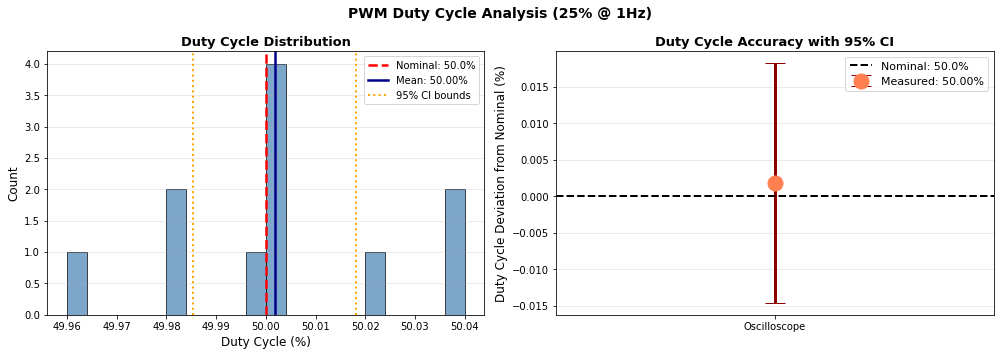

In [59]:
if __name__ == "__main__":
    results = analyze_duty_cycle(
        "action_2hz_kernel.csv",
        nominal_duty=50.0,
        nominal_freq=2.0,
        threshold=2.0,
        invert=True
    )
    
    if results is not None:
        fig = plot_duty_cycle_results(results, nominal_duty=50.0, nominal_freq=2.0)
        
        create_summary_table(results, nominal_duty=50.0, nominal_freq=2.0)
        
        plt.show()
    else:
        print("Analysis failed. Check your threshold and data.")

In [60]:
import pandas as pd
import numpy as np
import scipy.stats as stats  
import matplotlib.pyplot as plt

data = pd.read_csv("action_2hz_kernel.csv")

data["Volt"] = data["Volt"].astype(str).str.replace("+", "", regex=False).astype(float)
v = data["Volt"].to_numpy()
t = data["second"].to_numpy()

high_mask = v > 3.0      
low_mask  = v < 0.5     

v_high = v[high_mask]
v_low = v[low_mask]

ci_high = stats.t.interval(
    0.95, len(v_high)-1, loc=np.mean(v_high), scale=stats.sem(v_high)
)

ci_low = stats.t.interval(
    0.95, len(v_low)-1, loc=np.mean(v_low), scale=stats.sem(v_low)
)

print("95% Confidence Interval (High level):", ci_high)
print("95% Confidence Interval (Low level):", ci_low)


95% Confidence Interval (High level): (3.0313849761100466, 3.031716381480701)
95% Confidence Interval (Low level): (0.4421530284644957, 0.4424810427124832)


## Action LED at 5 Hz Analysis


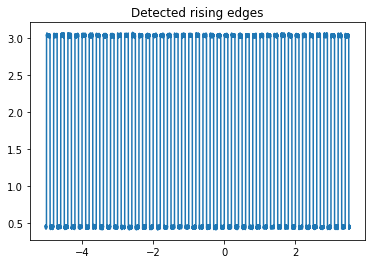

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("action_5hz_kernel.csv")

t = data["second"].to_numpy()
v = data["Volt"].to_numpy()

v = data["Volt"].astype(str).str.replace('+', '', regex=False).astype(float)

dv = np.diff(v)

low_th = 1.0    
high_th = 2.5   

is_high = v > high_th

edges = np.where(np.diff(is_high.astype(int)) == 1)[0]

t_edges = t[edges]
v_edges = v[edges]

plt.plot(t, v)
plt.title("Detected rising edges")
plt.show()



Voltage range: 0.404 to 3.078 V
Threshold: 2.5 V

DUTY CYCLE:
   Mean: 50.082%
   Std Dev: 0.050%
   95% CI: [50.066%, 50.098%]
   Nominal: 50.000%
   Error: 0.082% (0.16% relative error)

PULSE WIDTH (HIGH time):
   Mean: 100.171 ms
   Std Dev: 0.129 ms
   Expected (25% of 1s): 100.000 ms


Parameter                 Measured             Nominal         Error          
----------------------------------------------------------------------
Duty Cycle                50.082 ± 0.016%      50.000%        0.082%
Pulse Width               100.171 ± 0.040 ms   100.000 ms       0.171 ms
Frequency                 4.999645 ± 0.001055 Hz  5.000000 Hz  -0.000355 Hz
Period                    0.200014 ± 0.000042 s  0.200000 s    0.000014 s


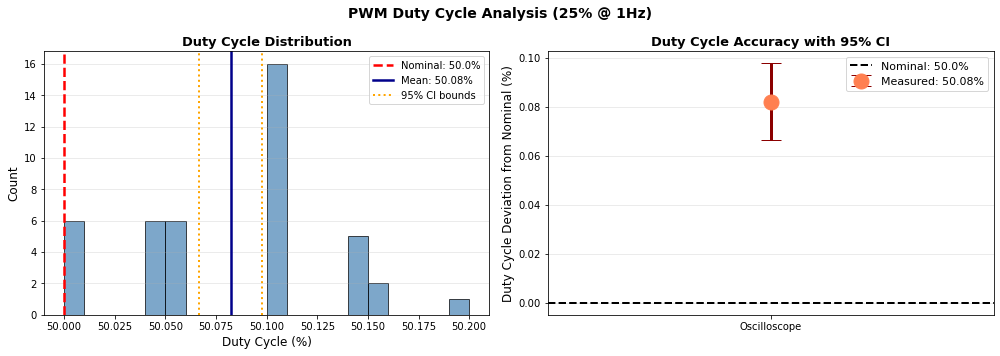

In [62]:
if __name__ == "__main__":
    results = analyze_duty_cycle(
        "action_5hz_kernel.csv",
        nominal_duty=50.0,
        nominal_freq=5.0,
        threshold=2.5,
        invert=True 
    )
    
    if results is not None:
        fig = plot_duty_cycle_results(results, nominal_duty=50.0, nominal_freq=5.0)
        
        create_summary_table(results, nominal_duty=50.0, nominal_freq=5.0)
        
        plt.show()
    else:
        print("Analysis failed. Check your threshold and data.")

In [63]:
import pandas as pd
import numpy as np
import scipy.stats as stats  
import matplotlib.pyplot as plt

data = pd.read_csv("action_5hz_kernel.csv")

data["Volt"] = data["Volt"].astype(str).str.replace("+", "", regex=False).astype(float)
v = data["Volt"].to_numpy()
t = data["second"].to_numpy()

high_mask = v > 3.0     
low_mask  = v < 0.5      

v_high = v[high_mask]
v_low = v[low_mask]

ci_high = stats.t.interval(
    0.95, len(v_high)-1, loc=np.mean(v_high), scale=stats.sem(v_high)
)

ci_low = stats.t.interval(
    0.95, len(v_low)-1, loc=np.mean(v_low), scale=stats.sem(v_low)
)

print("95% Confidence Interval (High level):", ci_high)
print("95% Confidence Interval (Low level):", ci_low)


95% Confidence Interval (High level): (3.033687495561872, 3.033969590105773)
95% Confidence Interval (Low level): (0.4426139902856922, 0.44289304529915124)


# Discussion & Results

Based off of my data analysis, we can tell that the led duty cycle and 95% confidence interval are very simialar to previous lab checkpoints and are around (very close) to the ideal / nominal values we want to see. 

### Heartbeat LED at 25% Duty Cycle

For the heartbeat LED at 25% duty cycle (and 1 Hz), I calculated a 95% CI: [25.000%, 25.018%] for the duty cycle, a 95% Confidence Interval (High level): (3.022413090576337, 3.022627210743827), and a 95% Confidence Interval (Low level): (0.4309959386653013, 0.43140001199045264), which are less about functionality but we can see that the ON and OFF ranges for the LED are where we want to see them. I also calculated a frequency of 0.999800 +/- 0.000000 Hz based on the data set which is very close to what we want to see. Any deviations from the ideal 25% duty cycle, 1 Hz frequency or 0V OFF and 3.3V ON could be due to latnecy and / or noise within the oscilliscope machine.

### Action LED at 1 Hz

For the action LED at 1 Hz frequency, I calculated a 95% CI: [49.994%, 50.004%] for the duty cycle, a 95% Confidence Interval (High level): (3.0322588374037256, 3.0325211518463453), and a 95% Confidence Interval (Low level): (0.44244421402408846, 0.4427014234909223), which are less about functionality but we can see that the ON and OFF ranges for the LED are where we want to see them. I also calculated a frequency of 0.999978 +/- 0.000092 Hz based on the data set which is very close to what we want to see. Any deviations from the ideal 50% duty cycle, 1 Hz frequency or 0V OFF and 3.3V ON could be due to latnecy and / or noise within the oscilliscope machine.

### Action LED at 2 Hz

For the action LED at 2 Hz frequency, I calculated a 95% CI: [49.985%, 50.018%] for the duty cycle, a 95% Confidence Interval (High level): (3.0313849761100466, 3.031716381480701), and a 95% Confidence Interval (Low level): (0.4421530284644957, 0.4424810427124832), which are less about functionality but we can see that the ON and OFF ranges for the LED are where we want to see them. I also calculated a frequency of 1.999927 +/- 0.000290 Hz based on the data set which is very close to what we want to see. Any deviations from the ideal 50% duty cycle, 2 Hz frequency or 0V OFF and 3.3V ON could be due to latnecy and / or noise within the oscilliscope machine.

### Action LED at 5 Hz

For the action LED at 5 Hz frequency, I calculated a 95% CI: [50.066%, 50.098%] for the duty cycle, a 95% Confidence Interval (High level): (3.033687495561872, 3.033969590105773), and a 95% Confidence Interval (Low level): (0.4426139902856922, 0.44289304529915124), which are less about functionality but we can see that the ON and OFF ranges for the LED are where we want to see them. I also calculated a frequency of 4.999645 +/- 0.001055 Hz based on the data set which is very close to what we want to see. Any deviations from the ideal 50% duty cycle, 5 Hz frequency or 0V OFF and 3.3V ON could be due to latnecy and / or noise within the oscilliscope machine.